# Clasificador de noticias: periódico, ideología y tema


## 1. Librerías

In [1]:
!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42
OUTPUT_DIR = Path("resultados_entrega_clasificacion")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Carga directa del CSV


In [3]:
import pandas as pd

df = pd.read_csv("datos_modelo.csv")

df["periodico"] = df["periodico"].astype(str).str.strip()
df["ideologia"] = df["ideologia"].astype(str).str.strip().str.lower()

print(df.shape)
print(df["periodico"].value_counts())
print(df["ideologia"].value_counts())

(10000, 14)
periodico
eldiario.es            2000
la razon               2000
Público                2000
Tercera Información    2000
el español             2000
Name: count, dtype: int64
ideologia
izquierda    6000
derecha      4000
Name: count, dtype: int64


## 3. Variables usadas

Variables predictoras:

- `x_0`
- `x_1`
- `x_2`
- `x_3`
- `x_4`
- `polaridad`

Variables objetivo:

- `periodico`
- `ideologia`
- `id_tema`


In [4]:
feature_cols = ["x_0", "x_1", "x_2", "x_3", "x_4", "polaridad"]
target_cols = ["periodico", "ideologia", "id_tema"]

X = df[feature_cols].copy()

print("Variables predictoras:", feature_cols)
print("Objetivos:", target_cols)


Variables predictoras: ['x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'polaridad']
Objetivos: ['periodico', 'ideologia', 'id_tema']


## 4. Resumen del dataset

In [5]:
resumen_dataset = pd.DataFrame({
    "metrica": [
        "num_filas",
        "num_columnas",
        "num_periodicos",
        "num_clases_ideologia",
        "num_temas"
    ],
    "valor": [
        len(df),
        df.shape[1],
        df["periodico"].nunique(),
        df["ideologia"].nunique(),
        df["id_tema"].nunique()
    ]
})

resumen_dataset.to_csv(OUTPUT_DIR / "resumen_dataset.csv", index=False)
resumen_dataset


,metrica,valor
0,num_filas,10000
1,num_columnas,14
2,num_periodicos,5
3,num_clases_ideologia,2
4,num_temas,5


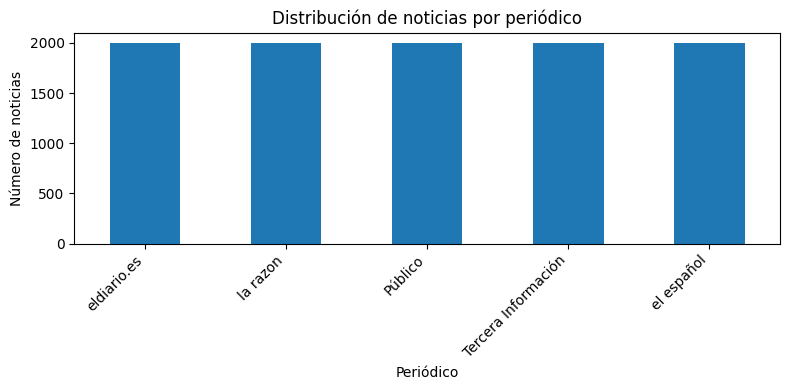

In [6]:
plt.figure(figsize=(8, 4))
df["periodico"].value_counts().plot(kind="bar")
plt.title("Distribución de noticias por periódico")
plt.xlabel("Periódico")
plt.ylabel("Número de noticias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribucion_periodicos.png", dpi=150)
plt.show()

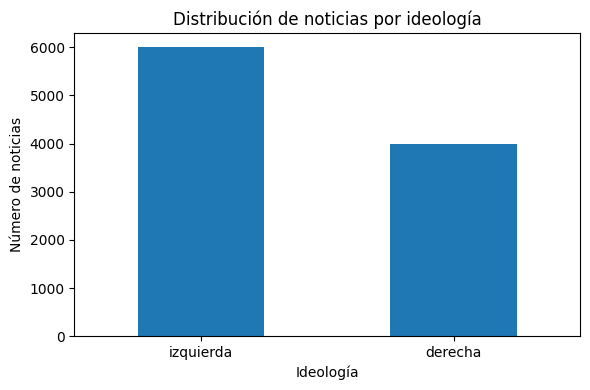

In [7]:
plt.figure(figsize=(6, 4))
df["ideologia"].value_counts().plot(kind="bar")
plt.title("Distribución de noticias por ideología")
plt.xlabel("Ideología")
plt.ylabel("Número de noticias")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribucion_ideologia.png", dpi=150)
plt.show()

## 5. Función de entrenamiento y evaluación

In [9]:
def train_and_evaluate_objective(df, objective, feature_cols, output_dir):
    X = df[feature_cols].copy()
    y_raw = df[objective].astype(str).copy()

    encoder = LabelEncoder()
    y = encoder.fit_transform(y_raw)
    class_names = [str(c) for c in encoder.classes_]

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X,
        y,
        df.index,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    models = {
        "Random_Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob" if len(class_names) > 2 else "binary:logistic",
            eval_metric="mlogloss" if len(class_names) > 2 else "logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    metrics_rows = []
    predictions = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        f1_weighted = f1_score(y_test, y_pred, average="weighted")

        metrics_rows.append({
            "objetivo": objective,
            "modelo": model_name,
            "accuracy": acc,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted
        })

        cols_base = ["periodico", "titulo", "texto", "url", "ideologia", "id_tema"]
        cols_base = [c for c in cols_base if c in df.columns]

        pred_df = df.loc[idx_test, cols_base].copy()
        pred_df["objetivo"] = objective
        pred_df["modelo"] = model_name
        pred_df["real"] = encoder.inverse_transform(y_test)
        pred_df["predicho"] = encoder.inverse_transform(y_pred)
        pred_df["correcto"] = pred_df["real"] == pred_df["predicho"]
        pred_df["confianza"] = y_proba.max(axis=1)

        predictions[model_name] = pred_df

        pred_df.to_csv(
            output_dir / f"predicciones_{objective}_{model_name}.csv",
            index=False
        )

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        fig, ax = plt.subplots(figsize=(7, 6))
        disp.plot(ax=ax, xticks_rotation=45, values_format="d")
        ax.set_title(f"Matriz de confusión - {objective} - {model_name}")
        plt.tight_layout()
        plt.savefig(output_dir / f"matriz_confusion_{objective}_{model_name}.png", dpi=150)
        plt.show()

        print("," "="*70)
        print(f"Objetivo: {objective} | Modelo: {model_name}")
        print("="*70)
        print(classification_report(y_test, y_pred, target_names=class_names))

    metrics_df = pd.DataFrame(metrics_rows)

    return {
        "metrics": metrics_df,
        "predictions": predictions,
        "classes": class_names
    }


## 6. Entrenamiento de modelos

OBJETIVO: periodico


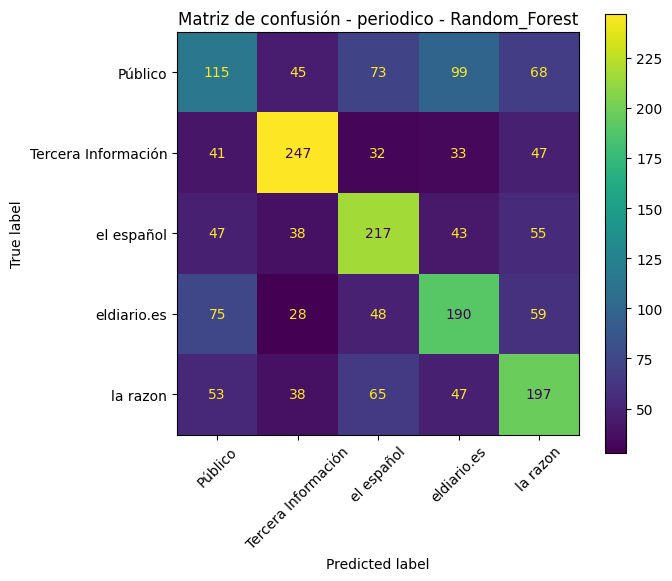

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: periodico | Modelo: Random_Forest
                     precision    recall  f1-score   support

            Público       0.35      0.29      0.31       400
Tercera Información       0.62      0.62      0.62       400
         el español       0.50      0.54      0.52       400
        eldiario.es       0.46      0.47      0.47       400
           la razon       0.46      0.49      0.48       400

           accuracy                           0.48      2000
          macro avg       0.48      0.48      0.48      2000
       weighted avg       0.48      0.48      0.48      2000



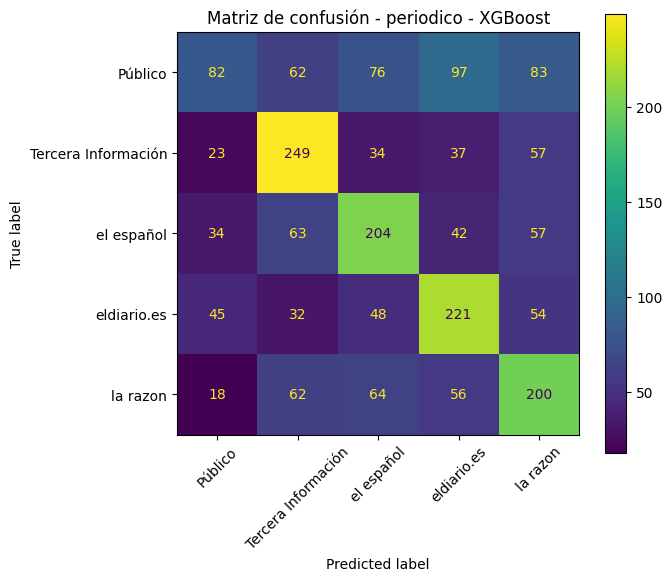

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: periodico | Modelo: XGBoost
                     precision    recall  f1-score   support

            Público       0.41      0.20      0.27       400
Tercera Información       0.53      0.62      0.57       400
         el español       0.48      0.51      0.49       400
        eldiario.es       0.49      0.55      0.52       400
           la razon       0.44      0.50      0.47       400

           accuracy                           0.48      2000
          macro avg       0.47      0.48      0.47      2000
       weighted avg       0.47      0.48      0.47      2000

OBJETIVO: ideologia


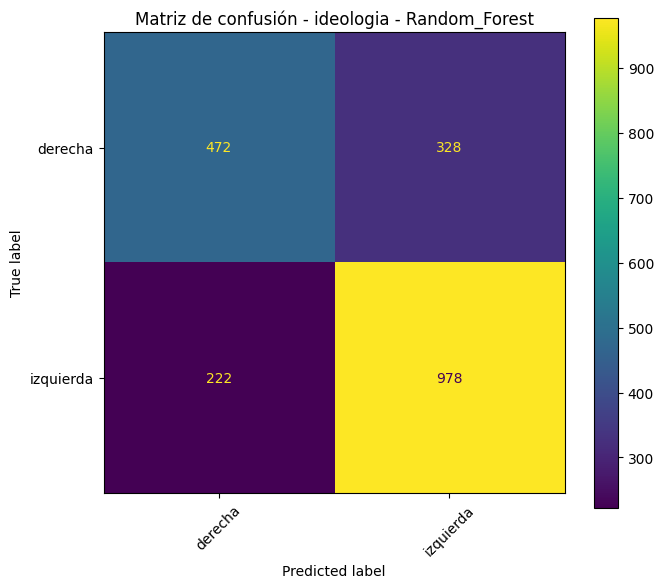

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: ideologia | Modelo: Random_Forest
              precision    recall  f1-score   support

     derecha       0.68      0.59      0.63       800
   izquierda       0.75      0.81      0.78      1200

    accuracy                           0.72      2000
   macro avg       0.71      0.70      0.71      2000
weighted avg       0.72      0.72      0.72      2000



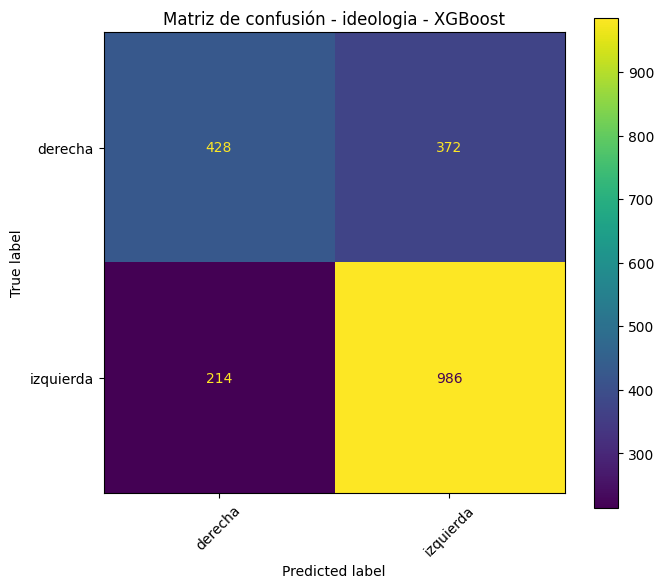

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: ideologia | Modelo: XGBoost
              precision    recall  f1-score   support

     derecha       0.67      0.54      0.59       800
   izquierda       0.73      0.82      0.77      1200

    accuracy                           0.71      2000
   macro avg       0.70      0.68      0.68      2000
weighted avg       0.70      0.71      0.70      2000

OBJETIVO: id_tema


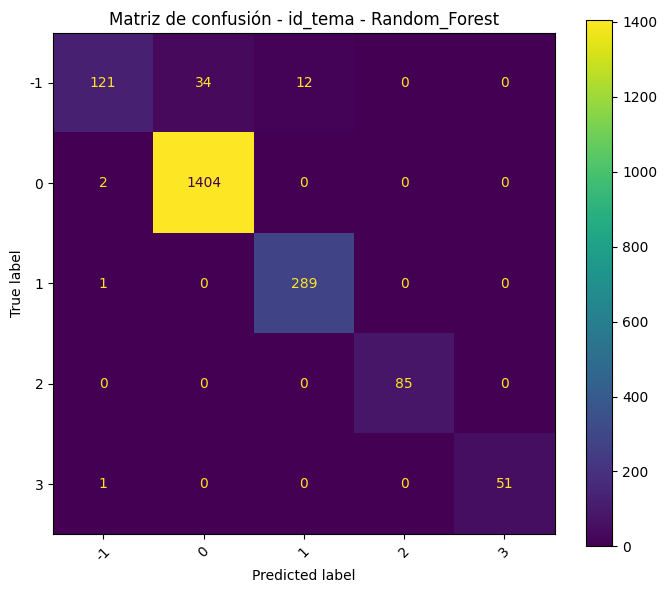

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: id_tema | Modelo: Random_Forest
              precision    recall  f1-score   support

          -1       0.97      0.72      0.83       167
           0       0.98      1.00      0.99      1406
           1       0.96      1.00      0.98       290
           2       1.00      1.00      1.00        85
           3       1.00      0.98      0.99        52

    accuracy                           0.97      2000
   macro avg       0.98      0.94      0.96      2000
weighted avg       0.97      0.97      0.97      2000



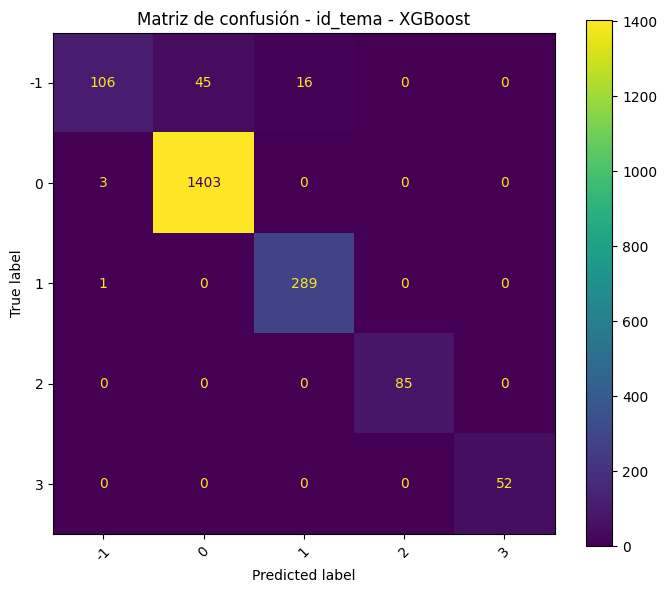

,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=,=
Objetivo: id_tema | Modelo: XGBoost
              precision    recall  f1-score   support

          -1       0.96      0.63      0.77       167
           0       0.97      1.00      0.98      1406
           1       0.95      1.00      0.97       290
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00        52

    accuracy                           0.97      2000
   macro avg       0.98      0.93      0.94      2000
weighted avg       0.97      0.97      0.96      2000



In [10]:
results = {}

for objective in target_cols:
    print("=" * 80)
    print(f"OBJETIVO: {objective}")
    print("=" * 80)
    results[objective] = train_and_evaluate_objective(
        df=df,
        objective=objective,
        feature_cols=feature_cols,
        output_dir=OUTPUT_DIR
    )

## 7. Tabla de métricas finales

In [11]:
tabla_metricas = pd.concat(
    [results[obj]["metrics"] for obj in target_cols],
    ignore_index=True
)

tabla_metricas = tabla_metricas.sort_values(["objetivo", "f1_macro"], ascending=[True, False])
tabla_metricas.to_csv(OUTPUT_DIR / "tabla_metricas_modelos.csv", index=False)

tabla_metricas

,objetivo,modelo,accuracy,f1_macro,f1_weighted
4,id_tema,Random_Forest,0.9750,0.956881,0.973361
5,id_tema,XGBoost,0.9675,0.943991,0.964440
2,ideologia,Random_Forest,0.7250,0.706194,0.721060
3,ideologia,XGBoost,0.7070,0.682267,0.699997
0,periodico,Random_Forest,0.4830,0.479996,0.479996
1,periodico,XGBoost,0.4780,0.465662,0.465662


In [12]:
mejor_modelo_por_objetivo = (
    tabla_metricas
    .sort_values(["objetivo", "f1_macro"], ascending=[True, False])
    .groupby("objetivo")
    .head(1)
    .reset_index(drop=True)
)

mejor_modelo_por_objetivo.to_csv(
    OUTPUT_DIR / "mejor_modelo_por_objetivo.csv",
    index=False
)

mejor_modelo_por_objetivo

,objetivo,modelo,accuracy,f1_macro,f1_weighted
0,id_tema,Random_Forest,0.975,0.956881,0.973361
1,ideologia,Random_Forest,0.725,0.706194,0.721060
2,periodico,Random_Forest,0.483,0.479996,0.479996


## 8. Resultados específicos de ideología

In [13]:
metricas_ideologia = tabla_metricas[tabla_metricas["objetivo"] == "ideologia"].copy()
metricas_ideologia = metricas_ideologia.sort_values("f1_macro", ascending=False)
metricas_ideologia.to_csv(OUTPUT_DIR / "metricas_ideologia.csv", index=False)
metricas_ideologia

,objetivo,modelo,accuracy,f1_macro,f1_weighted
2,ideologia,Random_Forest,0.725,0.706194,0.721060
3,ideologia,XGBoost,0.707,0.682267,0.699997


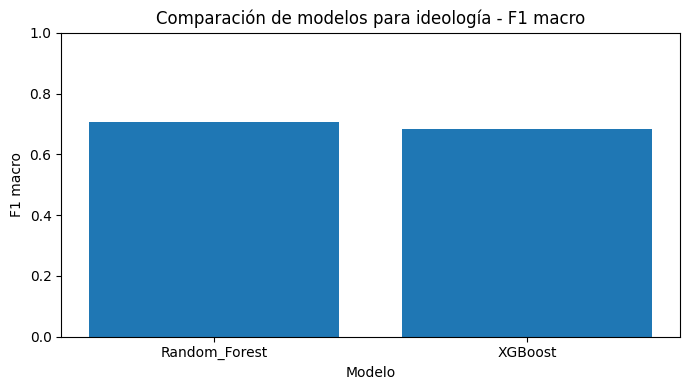

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(metricas_ideologia["modelo"], metricas_ideologia["f1_macro"])
plt.title("Comparación de modelos para ideología - F1 macro")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparacion_modelos_ideologia_f1_macro.png", dpi=150)
plt.show()

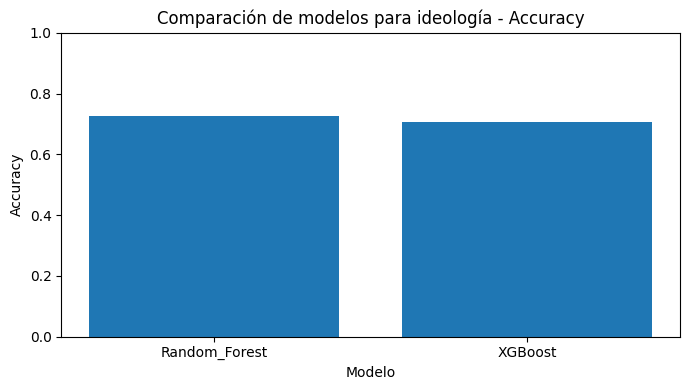

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(metricas_ideologia["modelo"], metricas_ideologia["accuracy"])
plt.title("Comparación de modelos para ideología - Accuracy")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparacion_modelos_ideologia_accuracy.png", dpi=150)
plt.show()

## 9. Modelo final para ideología

Se selecciona automáticamente el modelo con mayor `f1_macro` en la tarea de ideología.

In [16]:
modelo_final_ideologia = metricas_ideologia.iloc[0]["modelo"]
print("Modelo final para ideología:", modelo_final_ideologia)

predicciones_finales_ideologia = results["ideologia"]["predictions"][modelo_final_ideologia].copy()

predicciones_finales_ideologia.to_csv(
    OUTPUT_DIR / "predicciones_ideologia_modelo_final.csv",
    index=False
)

predicciones_finales_ideologia.head()

Modelo final para ideología: Random_Forest


,periodico,titulo,texto,url,ideologia,id_tema,objetivo,modelo,real,predicho,correcto,confianza
6410,Tercera Información,Manifiesto leído en la concentración frente al...,Estamos aquí porque no vamos a permitir que el...,https://www.tercerainformacion.es/opinion/03/0...,izquierda,0,ideologia,Random_Forest,izquierda,izquierda,True,0.703333
3884,la razon,"Señorito, estamos tirando el dinero","Con los datos del CIS, sólo la torpeza explica...",https://www.larazon.es/opinion/senorito-estamo...,derecha,0,ideologia,Random_Forest,derecha,derecha,True,0.610000
7203,Tercera Información,Palestina: genocidio y hambruna,Cristóbal León Campos • Opinión • 08/08/2025 E...,https://www.tercerainformacion.es/opinion/08/0...,izquierda,2,ideologia,Random_Forest,izquierda,izquierda,True,0.923333
5073,Público,El momento de los hijos e hijas de migrantes e...,"Hace pocos días, Zohran Mamdani pronunciaba un...",https://www.publico.es/opinion/columnas/moment...,izquierda,0,ideologia,Random_Forest,izquierda,izquierda,True,0.776667
5915,Público,Lady pinganillo,Hay diversas razones por las que Ayuso abandon...,https://www.publico.es/opinion/columnas/lady-p...,izquierda,0,ideologia,Random_Forest,izquierda,derecha,False,0.716667


## 10. Análisis de errores del modelo final

In [17]:
errores_ideologia = predicciones_finales_ideologia[
    predicciones_finales_ideologia["correcto"] == False
].copy()

errores_ideologia = errores_ideologia.sort_values("confianza", ascending=False)

errores_ideologia.to_csv(
    OUTPUT_DIR / "errores_ideologia_modelo_final.csv",
    index=False
)

print("Total predicciones test:", len(predicciones_finales_ideologia))
print("Errores:", len(errores_ideologia))
print("Aciertos:", predicciones_finales_ideologia["correcto"].sum())

errores_ideologia.head(20)

Total predicciones test: 2000
Errores: 550
Aciertos: 1450


,periodico,titulo,texto,url,ideologia,id_tema,objetivo,modelo,real,predicho,correcto,confianza
9191,el español,por qué el movimiento maga se mantiene leal a ...,donald trump durante un discurso ante miembros...,https://www.elespanol.com/opinion/columnas/202...,derecha,1,ideologia,Random_Forest,derecha,izquierda,False,0.990000
9696,el español,¿cómo desconectar del ruido mediático en la 'e...,una adolescente consulta su teléfono móvil.efe...,https://www.elespanol.com/opinion/columnas/202...,derecha,-1,ideologia,Random_Forest,derecha,izquierda,False,0.986667
8799,el español,el nefasto decreto ley de alquileres,"isabel rodríguez garcía, ministra de vivienda....",https://www.elespanol.com/opinion/tribunas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.986667
8544,el español,la chatisfera,"irene montero, feliz. la narrativa oficial nos...",https://www.elespanol.com/opinion/columnas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.986667
3180,la razon,Jessica es dentista,"Ábalos es, en todos los sentidos, una de esas ...",https://www.larazon.es/opinion/jessica-dentist...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.980000
5757,Público,Elon Musk quiere fundar su propio Partido,"Esta semana se aprobaba en el Senado, tras cua...",https://www.publico.es/opinion/elon-musk-quier...,izquierda,0,ideologia,Random_Forest,izquierda,derecha,False,0.980000
2876,la razon,La excusa del cambio climático,"Lejos de pedir perdón, asumir los errores y po...",https://www.larazon.es/opinion/excusa-cambio-c...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.973333
9104,el español,las lágrimas de mario vargas llosa,"mario vargas llosa, en febrero de 2023. a un e...",https://www.elespanol.com/opinion/tribunas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.966667
8967,el español,"la guerra contra el régimen iraní, entre la de...",los residentes de un edificio en tel aviv reco...,https://www.elespanol.com/opinion/tribunas/202...,derecha,3,ideologia,Random_Forest,derecha,izquierda,False,0.960000
8502,el español,aladina y la lámpara maravillosa,la envidia a la española tiene como principal ...,https://www.elespanol.com/opinion/carta-del-di...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.960000


In [18]:
errores_alta_confianza = errores_ideologia[
    errores_ideologia["confianza"] >= 0.70
].copy()

errores_alta_confianza.to_csv(
    OUTPUT_DIR / "errores_ideologia_alta_confianza.csv",
    index=False
)

errores_alta_confianza.head(20)

,periodico,titulo,texto,url,ideologia,id_tema,objetivo,modelo,real,predicho,correcto,confianza
9191,el español,por qué el movimiento maga se mantiene leal a ...,donald trump durante un discurso ante miembros...,https://www.elespanol.com/opinion/columnas/202...,derecha,1,ideologia,Random_Forest,derecha,izquierda,False,0.990000
9696,el español,¿cómo desconectar del ruido mediático en la 'e...,una adolescente consulta su teléfono móvil.efe...,https://www.elespanol.com/opinion/columnas/202...,derecha,-1,ideologia,Random_Forest,derecha,izquierda,False,0.986667
8799,el español,el nefasto decreto ley de alquileres,"isabel rodríguez garcía, ministra de vivienda....",https://www.elespanol.com/opinion/tribunas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.986667
8544,el español,la chatisfera,"irene montero, feliz. la narrativa oficial nos...",https://www.elespanol.com/opinion/columnas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.986667
3180,la razon,Jessica es dentista,"Ábalos es, en todos los sentidos, una de esas ...",https://www.larazon.es/opinion/jessica-dentist...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.980000
5757,Público,Elon Musk quiere fundar su propio Partido,"Esta semana se aprobaba en el Senado, tras cua...",https://www.publico.es/opinion/elon-musk-quier...,izquierda,0,ideologia,Random_Forest,izquierda,derecha,False,0.980000
2876,la razon,La excusa del cambio climático,"Lejos de pedir perdón, asumir los errores y po...",https://www.larazon.es/opinion/excusa-cambio-c...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.973333
9104,el español,las lágrimas de mario vargas llosa,"mario vargas llosa, en febrero de 2023. a un e...",https://www.elespanol.com/opinion/tribunas/202...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.966667
8967,el español,"la guerra contra el régimen iraní, entre la de...",los residentes de un edificio en tel aviv reco...,https://www.elespanol.com/opinion/tribunas/202...,derecha,3,ideologia,Random_Forest,derecha,izquierda,False,0.960000
8502,el español,aladina y la lámpara maravillosa,la envidia a la española tiene como principal ...,https://www.elespanol.com/opinion/carta-del-di...,derecha,0,ideologia,Random_Forest,derecha,izquierda,False,0.960000


## Resultados específicos de tema


In [19]:
metricas_topic = tabla_metricas[tabla_metricas["objetivo"] == "id_tema"].copy()
metricas_topic = metricas_topic.sort_values("f1_macro", ascending=False)
metricas_topic.to_csv(OUTPUT_DIR / "metricas_topic.csv", index=False)
metricas_topic


,objetivo,modelo,accuracy,f1_macro,f1_weighted
4,id_tema,Random_Forest,0.9750,0.956881,0.973361
5,id_tema,XGBoost,0.9675,0.943991,0.964440


In [20]:
modelo_final_topic = metricas_topic.iloc[0]["modelo"]
print("Modelo final para tema:", modelo_final_topic)

predicciones_finales_topic = results["id_tema"]["predictions"][modelo_final_topic].copy()

predicciones_finales_topic.to_csv(
    OUTPUT_DIR / "predicciones_topic_modelo_final.csv",
    index=False
)

predicciones_finales_topic.head()


Modelo final para tema: Random_Forest


,periodico,titulo,texto,url,ideologia,id_tema,objetivo,modelo,real,predicho,correcto,confianza
6010,Tercera Información,Isabel Allende: «Necesito trescientas páginas ...,Jaafar Al Aluni • Opinión • 01/05/2026 Isabel ...,https://www.tercerainformacion.es/opinion/01/0...,izquierda,2,id_tema,Random_Forest,2,2,True,0.910000
2745,la razon,Dos visiones contrapuestas,Este «contubernio» progresista de Barcelona ha...,https://www.larazon.es/opinion/dos-visiones-co...,derecha,0,id_tema,Random_Forest,0,0,True,1.000000
6027,Tercera Información,El hoy es un mundo unipolar estadounidense,Rómulo Pardo Silva • Opinión • 26/04/2026 El P...,https://www.tercerainformacion.es/opinion/25/0...,izquierda,1,id_tema,Random_Forest,1,1,True,0.983333
558,eldiario.es,El último vals de Nacho Para,En varios momentos de la noche del pasado juev...,https://www.eldiario.es/murcia/murcia-y-aparte...,izquierda,0,id_tema,Random_Forest,0,0,True,0.993333
5202,Público,El estupor de un juez,Cuando la política penetra en el Palacio de Ju...,https://www.publico.es/opinion/columnas/estupo...,izquierda,0,id_tema,Random_Forest,0,0,True,0.993333


In [21]:
errores_topic = predicciones_finales_topic[
    predicciones_finales_topic["correcto"] == False
].copy()

errores_topic = errores_topic.sort_values("confianza", ascending=False)

errores_topic.to_csv(
    OUTPUT_DIR / "errores_topic_modelo_final.csv",
    index=False
)

print("Total predicciones test:", len(predicciones_finales_topic))
print("Errores:", len(errores_topic))
print("Aciertos:", predicciones_finales_topic["correcto"].sum())

errores_topic.head(20)


Total predicciones test: 2000
Errores: 50
Aciertos: 1950


,periodico,titulo,texto,url,ideologia,id_tema,objetivo,modelo,real,predicho,correcto,confianza
9754,el español,"sánchez, la prostitución y el segundo chiste d...","el ambiente en moncloa no es de fin de curso, ...",https://www.elespanol.com/opinion/carta-del-di...,derecha,-1,id_tema,Random_Forest,-1,0,False,0.990000
2256,la razon,Buscando una nueva presa,"Eliminado Mazón, ahora van a por Ayuso, Moreno...",https://www.larazon.es/opinion/buscando-nueva-...,derecha,-1,id_tema,Random_Forest,-1,0,False,0.983333
6343,Tercera Información,Portugal nos enseña la unidad como apuesta,Eduardo Madroñal Pedraza • Opinión • 22/02/202...,https://www.tercerainformacion.es/opinion/22/0...,izquierda,-1,id_tema,Random_Forest,-1,0,False,0.983333
3564,la razon,El poder de Warren nos libera,"Somos libres para no ser libres, y el poder es...",https://www.larazon.es/opinion/poder-warren-no...,derecha,-1,id_tema,Random_Forest,-1,0,False,0.963333
1467,eldiario.es,Liberen los parques y el ocio,"Te propongo un juego. Si te digo ocio, ¿qué se...",https://www.eldiario.es/andalucia/desdeelsur/l...,izquierda,-1,id_tema,Random_Forest,-1,0,False,0.943333
4828,Público,Sobre la imprenta y los medios como constructo...,Ya todo ha cambiado. De forma acelerada ha cam...,https://www.publico.es/opinion/columnas/sobre-...,izquierda,-1,id_tema,Random_Forest,-1,0,False,0.936667
5805,Público,¿Qué tiene que ver el Orgullo con el genocidio...,La películaPride(2014) cuenta la historia de l...,https://www.publico.es/opinion/columnas/ver-or...,izquierda,-1,id_tema,Random_Forest,-1,0,False,0.910000
5714,Público,El Tribunal Supremo debe garantizar la transpa...,"Esta semana, las compañeras de Civiohan hecho ...",https://www.publico.es/opinion/columnas/tribun...,izquierda,-1,id_tema,Random_Forest,-1,0,False,0.906667
6564,Tercera Información,Ante la agresión imperialista contra Venezuela,El Partido Comunista de los Trabajadores de Es...,https://www.tercerainformacion.es/opinion/03/0...,izquierda,-1,id_tema,Random_Forest,-1,1,False,0.896667
2265,la razon,Calamidad sobre calamidad,La construcción de cientos de miles de viviend...,https://www.larazon.es/opinion/calamidad-calam...,derecha,-1,id_tema,Random_Forest,-1,0,False,0.893333


## 11. Importancia de variables del modelo final

Las variables `x_0` a `x_4` no son palabras concretas, sino dimensiones numéricas de la representación semántica. Por tanto, esta gráfica indica qué dimensiones han pesado más en el modelo, no qué términos concretos explican la predicción.

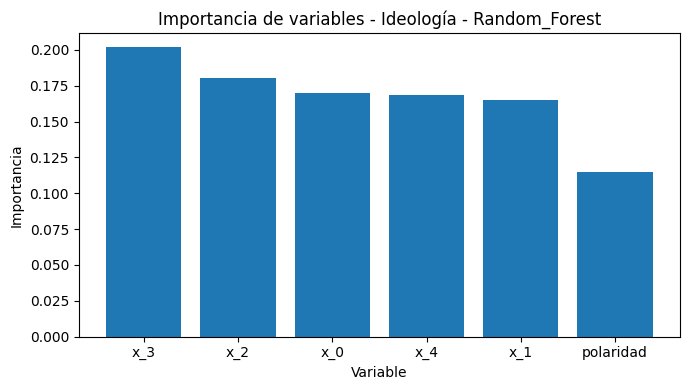

,variable,importancia
3,x_3,0.201738
2,x_2,0.180145
0,x_0,0.169968
4,x_4,0.168173
1,x_1,0.164831
5,polaridad,0.115145


In [22]:
# Reentrenar el modelo final de ideología con todo el dataset para obtener importancia de variables.
X_all = df[feature_cols].copy()
y_all_raw = df["ideologia"].copy()

encoder_final = LabelEncoder()
y_all = encoder_final.fit_transform(y_all_raw)

if modelo_final_ideologia == "Random_Forest":
    final_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
else:
    final_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

final_model.fit(X_all, y_all)

importancias = pd.DataFrame({
    "variable": feature_cols,
    "importancia": final_model.feature_importances_
}).sort_values("importancia", ascending=False)

importancias.to_csv(
    OUTPUT_DIR / "importancia_variables_ideologia_modelo_final.csv",
    index=False
)

plt.figure(figsize=(7, 4))
plt.bar(importancias["variable"], importancias["importancia"])
plt.title(f"Importancia de variables - Ideología - {modelo_final_ideologia}")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "importancia_variables_ideologia_modelo_final.png", dpi=150)
plt.show()

importancias

## 12. Conclusión automática para copiar al informe

In [23]:
mejor_ideo = metricas_ideologia.iloc[0]

print("Conclusión sugerida:\n")
print(
    f"El mejor modelo para predecir la ideología aproximada ha sido {mejor_ideo['modelo']}, "
    f"con una accuracy de {mejor_ideo['accuracy']:.3f} y un F1 macro de {mejor_ideo['f1_macro']:.3f}. "
    "Estos resultados indican que las variables semánticas utilizadas contienen información relacionada "
    "con el periódico de publicación y con la orientación ideológica asignada. Sin embargo, la ideología "
    "debe interpretarse como una aproximación construida a partir del medio, no como una etiqueta objetiva "
    "del contenido de cada noticia."
)

Conclusión sugerida:

El mejor modelo para predecir la ideología aproximada ha sido Random_Forest, con una accuracy de 0.725 y un F1 macro de 0.706. Estos resultados indican que las variables semánticas utilizadas contienen información relacionada con el periódico de publicación y con la orientación ideológica asignada. Sin embargo, la ideología debe interpretarse como una aproximación construida a partir del medio, no como una etiqueta objetiva del contenido de cada noticia.


## 13. Comprimir resultados para descargar

In [24]:
import shutil

shutil.make_archive(
    "resultados_entrega_clasificacion",
    "zip",
    "resultados_entrega_clasificacion"
)

print("Archivo creado: resultados_entrega_clasificacion.zip")

Archivo creado: resultados_entrega_clasificacion.zip


In [25]:
from google.colab import files
files.download("resultados_entrega_clasificacion.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

X = df[feature_cols]
y = df["ideologia"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_dummy)
baseline_f1 = f1_score(y_test, y_pred_dummy, average="macro")

print("Baseline accuracy:", baseline_accuracy)
print("Baseline F1 macro:", baseline_f1)

Baseline accuracy: 0.6
Baseline F1 macro: 0.375


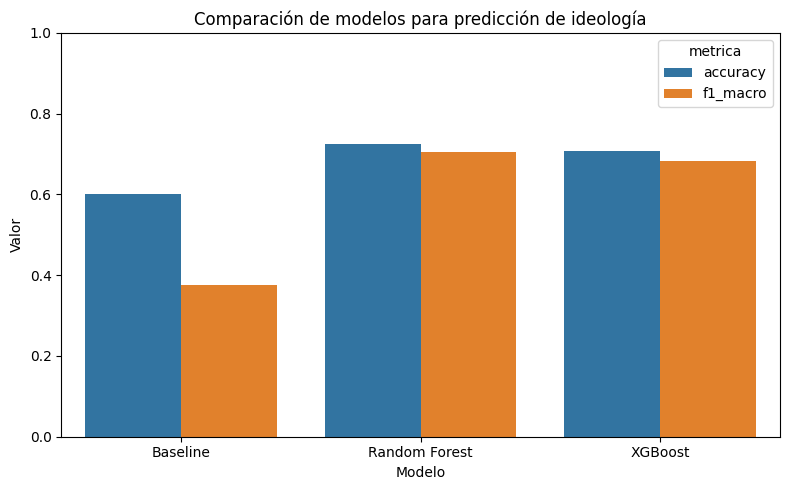

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

resumen_ideologia = pd.DataFrame({
    "modelo": ["Baseline", "Random Forest", "XGBoost"],
    "accuracy": [baseline_accuracy, 0.725, 0.707],
    "f1_macro": [baseline_f1, 0.706, 0.682]
})

resumen_melt = resumen_ideologia.melt(
    id_vars="modelo",
    value_vars=["accuracy", "f1_macro"],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=resumen_melt, x="modelo", y="valor", hue="metrica")
plt.ylim(0, 1)
plt.title("Comparación de modelos para predicción de ideología")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.tight_layout()
plt.savefig("resultados_entrega_clasificacion/comparacion_final_ideologia_baseline.png", dpi=150)
plt.show()
